In [ ]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

In [ ]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

BASE_DIR = os.path.join(
    os.path.dirname(os.getcwd()), "data", "task3"
) if "notebooks" in os.getcwd() else os.path.join("data", "task3")

TRAIN_DIR  = os.path.join(BASE_DIR, "train")
TEST_DIR   = os.path.join(BASE_DIR, "test")
LABELS_CSV = os.path.join(BASE_DIR, "train_labels.csv")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device     :", DEVICE)
print("BASE_DIR   :", BASE_DIR)
print("TRAIN_DIR  :", TRAIN_DIR)
print("TEST_DIR   :", TEST_DIR)
print("LABELS_CSV :", LABELS_CSV)

Device: cuda


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
LR_HEAD = 1e-3
LR_FINE = 1e-4
WEIGHT_DECAY = 1e-4
VAL_RATIO = 0.15

HEAD_EPOCHS = 10
HEAD_PATIENCE = 3

FINE_EPOCHS = 10
FINE_PATIENCE = 5

NUM_WORKERS = 0 

RUN_NAME = f"transfer_resnet18_img{IMG_SIZE}_lr{LR_HEAD}_bs{BATCH_SIZE}"
RUN_DIR  = os.path.join(os.path.dirname(BASE_DIR), "submissions", RUN_NAME)
os.makedirs(RUN_DIR, exist_ok=True)

CKPT_PATH = os.path.join(RUN_DIR, "best_model.pth")
SUBMISSION_PATH = os.path.join(RUN_DIR, "submission.csv")
HISTORY_PATH = os.path.join(RUN_DIR, "history.npy")
REPORT_PATH = os.path.join(RUN_DIR, "classification_report.txt")
CURVES_PATH = os.path.join(RUN_DIR, "training_curves.png")
CM_PATH = os.path.join(RUN_DIR, "confusion_matrix.png")
SUMMARY_PATH = os.path.join(RUN_DIR, "summary.txt")
CONFIG_PATH = os.path.join(RUN_DIR, "config.txt")

print(f"Run folder: {RUN_DIR}")

In [ ]:
df = pd.read_csv(LABELS_CSV)

print("\nDataset overview")
print("----------------")
print("Total samples:", len(df))
print("Columns:", df.columns.tolist())
print("Classes:", sorted(df["label"].unique()))
print("Number of classes:", df["label"].nunique())

Number of samples: 1194
Classes: ['Bug', 'Fighting', 'Fire', 'Grass', 'Ground', 'Normal', 'Poison', 'Rock', 'Water']
Num classes: 9


In [ ]:
le = LabelEncoder()
df["label_idx"] = le.fit_transform(df["label"])
NUM_CLASSES = len(le.classes_)

train_df, val_df = train_test_split(
    df,
    test_size=VAL_RATIO,
    stratify=df["label_idx"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("\nSplit overview")
print("--------------")
print("Train samples:", len(train_df))
print("Val samples  :", len(val_df))
print("Class mapping:", dict(enumerate(le.classes_)))

Train size: 1014
Val size: 180
Class mapping: {0: 'Bug', 1: 'Fighting', 2: 'Fire', 3: 'Grass', 4: 'Ground', 5: 'Normal', 6: 'Poison', 7: 'Rock', 8: 'Water'}


In [ ]:
class PokemonDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['Id']}.png")

        try:
            image = Image.open(img_path).convert("RGB")
            if self.transform:
                image = self.transform(image)

            label = int(row["label_idx"])
            return image, label
        except Exception as e:
            print(f"Error loading file: {img_path}")
            raise e


class PokemonTestDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.img_ids = sorted([
            f.replace(".png", "")
            for f in os.listdir(img_dir)
            if f.endswith(".png")
        ])

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_path = os.path.join(self.img_dir, f"{img_id}.png")

        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        return image, img_id

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [ ]:
train_dataset = PokemonDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset = PokemonDataset(val_df, TRAIN_DIR, transform=val_transform)

class_sample_counts = np.bincount(train_df["label_idx"])
weights_per_class = 1.0 / class_sample_counts
sample_weights = weights_per_class[train_df["label_idx"].values]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(train_dataset),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

X_batch, y_batch = next(iter(train_loader))
print("\nBatch check")
print("-----------")
print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)

In [ ]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Freeze backbone for stage 1
for param in model.parameters():
    param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(DEVICE)

print("\nModel ready")
print("-----------")
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
class_weights = torch.tensor(
    [1.0 / class_sample_counts[i] for i in range(NUM_CLASSES)],
    dtype=torch.float32
)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = class_weights.to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# optimizer = optim.AdamW(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)

# scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode="max",
#     factor=0.5,
#     patience=2
# )

In [ ]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(X)
            loss = criterion(logits, y)

            total_loss += loss.item() * len(y)

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return avg_loss, macro_f1, np.array(all_preds), np.array(all_labels)


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                device, max_epochs=10, patience=3, ckpt_path="best_model.pth"):

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_f1": []
    }

    best_val_f1 = -1.0
    best_state = None
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs}", leave=False)

        for X, y in progress_bar:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(y)

        train_loss = running_loss / len(train_loader.dataset)
        val_loss, val_f1, _, _ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)

        scheduler.step(val_f1)

        print(
            f"Epoch {epoch+1:02d}/{max_epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_macro_f1={val_f1:.4f}"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, ckpt_path)
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered after epoch {epoch+1}.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"Best validation Macro-F1: {best_val_f1:.4f}")
    return model, history, best_val_f1

In [22]:
X, y = next(iter(train_loader))
print(X.shape, y.shape)
print(X.dtype, y.dtype)

torch.Size([32, 3, 224, 224]) torch.Size([32])
torch.float32 torch.int64


In [23]:
img, label = train_dataset[0]
print(img.shape, label)

torch.Size([3, 224, 224]) 8


#### Classifier head training

In [ ]:
optimizer_head = optim.AdamW(
    model.fc.parameters(),
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY
)

scheduler_head = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_head,
    mode="max",
    factor=0.5,
    patience=2
)

print("\nStage 1 - Training classifier head")
print("----------------------------------")

model, history_stage1, best_f1_stage1 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_head,
    scheduler=scheduler_head,
    device=DEVICE,
    max_epochs=HEAD_EPOCHS,
    patience=HEAD_PATIENCE,
    ckpt_path=CKPT_PATH
)

Epoch 1/10:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1: train_loss=2.3011, val_loss=2.5381, val_f1=0.0137


Epoch 2/10:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2: train_loss=2.2124, val_loss=2.4201, val_f1=0.0284


Epoch 3/10:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 7: train_loss=1.9169, val_loss=2.3994, val_f1=0.0490


Epoch 8/10:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 8: train_loss=1.8901, val_loss=2.4736, val_f1=0.0245


Epoch 9/10:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 9: train_loss=1.9242, val_loss=2.4504, val_f1=0.0377
Early stopping triggered.
Best validation Macro-F1: 0.05827581561165692


#### Fine-Tuning

In [ ]:
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

optimizer_fine = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_FINE,
    weight_decay=WEIGHT_DECAY
)

scheduler_fine = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_fine,
    mode="max",
    factor=0.5,
    patience=2
)

print("\nStage 2 - Fine-tuning last block + classifier")
print("----------------------------------------------")

model, history_stage2, best_f1_stage2 = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_fine,
    scheduler=scheduler_fine,
    device=DEVICE,
    max_epochs=FINE_EPOCHS,
    patience=FINE_PATIENCE,
    ckpt_path=CKPT_PATH
)

Epoch 1/15:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1: train_loss=1.7750, val_loss=2.4969, val_f1=0.0628


Epoch 2/15:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 2: train_loss=1.5181, val_loss=2.5738, val_f1=0.0646


Epoch 3/15:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 13: train_loss=0.2377, val_loss=3.1618, val_f1=0.1596


Epoch 14/15:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 14: train_loss=0.2111, val_loss=3.1922, val_f1=0.1419


Epoch 15/15:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 15: train_loss=0.2026, val_loss=3.2797, val_f1=0.1486
Best validation Macro-F1: 0.15959054623741176


#### Final Evaluation

In [ ]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

val_loss, val_f1, all_preds, all_labels = evaluate(model, val_loader, criterion, DEVICE)

print("\n" + "=" * 60)
print("FINAL TRANSFER LEARNING RESULTS")
print("=" * 60)
print(f"Validation Loss    : {val_loss:.4f}")
print(f"Validation Macro-F1: {val_f1:.4f}")

report = classification_report(
    all_labels,
    all_preds,
    target_names=le.classes_,
    zero_division=0
)

print("\nClassification Report\n")
print(report)


TRANSFER LEARNING RESULTS
Validation Loss    : 3.1618
Validation Macro-F1: 0.1596

              precision    recall  f1-score   support

         Bug       0.18      0.26      0.21        23
    Fighting       0.00      0.00      0.00         9
        Fire       0.25      0.29      0.27        17
       Grass       0.37      0.29      0.33        24
      Ground       0.00      0.00      0.00        11
      Normal       0.14      0.15      0.14        33
      Poison       0.00      0.00      0.00        10
        Rock       0.20      0.20      0.20        15
       Water       0.35      0.24      0.28        38

    accuracy                           0.19       180
   macro avg       0.17      0.16      0.16       180
weighted avg       0.21      0.19      0.20       180



In [ ]:
history = {
    "train_loss": history_stage1["train_loss"] + history_stage2["train_loss"],
    "val_loss": history_stage1["val_loss"] + history_stage2["val_loss"],
    "val_f1": history_stage1["val_f1"] + history_stage2["val_f1"]
}

np.save(HISTORY_PATH, history, allow_pickle=True)

with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(report)

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    f.write("Task 3 - Transfer Learning\n")
    f.write(f"Model: ResNet18\n")
    f.write(f"Image size: {IMG_SIZE}\n")
    f.write(f"Batch size: {BATCH_SIZE}\n")
    f.write(f"Head learning rate: {LR_HEAD}\n")
    f.write(f"Fine-tuning learning rate: {LR_FINE}\n")
    f.write(f"Weight decay: {WEIGHT_DECAY}\n")
    f.write(f"Train samples: {len(train_df)}\n")
    f.write(f"Val samples: {len(val_df)}\n")
    f.write(f"Classes: {list(le.classes_)}\n")

with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    f.write("Task 3 - Transfer Learning Results\n")
    f.write(f"Validation Loss: {val_loss:.4f}\n")
    f.write(f"Validation Macro-F1: {val_f1:.4f}\n")
    f.write(f"Best checkpoint: {CKPT_PATH}\n")
    f.write(f"Submission path: {SUBMISSION_PATH}\n")

print(f"\nHistory saved to: {HISTORY_PATH}")
print(f"Report saved to : {REPORT_PATH}")
print(f"Config saved to : {CONFIG_PATH}")
print(f"Summary saved to: {SUMMARY_PATH}")

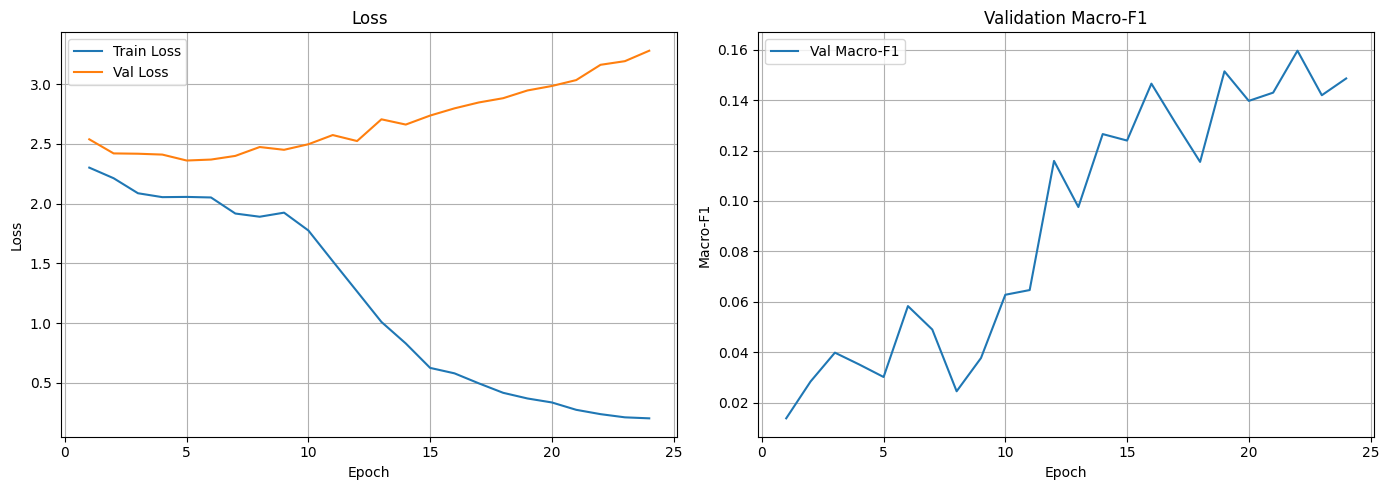

In [ ]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_ran, history["train_loss"], label="Train Loss")
plt.plot(epochs_ran, history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_ran, history["val_f1"], label="Val Macro-F1")
plt.title("Validation Macro-F1")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(CURVES_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Training curves saved to: {CURVES_PATH}")

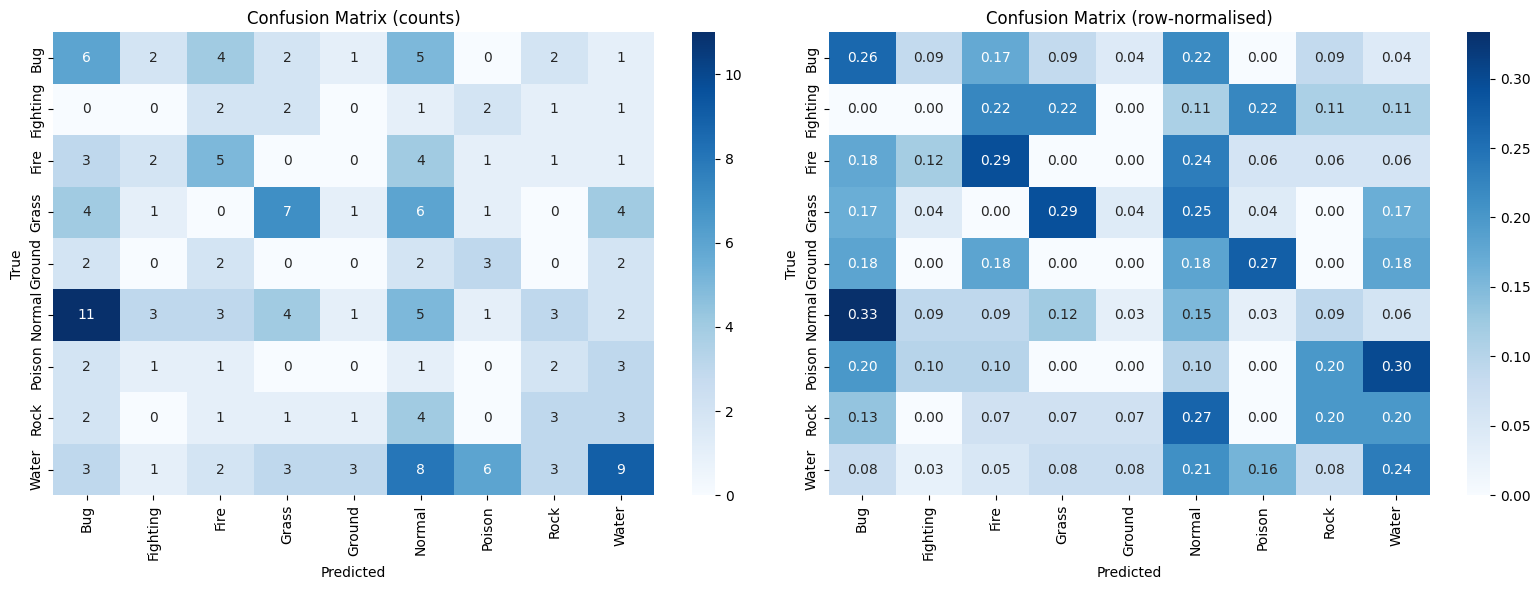

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix (counts)")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.subplot(1, 2, 2)
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("Confusion Matrix (row-normalised)")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.savefig(CM_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Confusion matrix saved to: {CM_PATH}")

In [ ]:
test_dataset = PokemonTestDataset(TEST_DIR, transform=val_transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

model.eval()
test_ids = []
test_preds = []

with torch.no_grad():
    for X, img_ids in tqdm(test_loader, desc="Predicting on test set"):
        X = X.to(DEVICE, non_blocking=True)
        logits = model(X)
        preds = logits.argmax(dim=1).cpu().numpy()

        test_ids.extend(img_ids)
        test_preds.extend(preds)

pred_labels = le.inverse_transform(test_preds)

submission = pd.DataFrame({
    "Id": test_ids,
    "label": pred_labels
})

submission.to_csv(SUBMISSION_PATH, index=False)

print(f"\nSubmission saved to: {SUBMISSION_PATH}")
print(f"Total predictions  : {len(submission)}")
print("\nPrediction distribution:")
print(submission["label"].value_counts().to_string())

submission.head(10)